In [ ]:
# Re-import libraries after kernel reset
from pathlib import Path
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import math
from collections import defaultdict
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import multiprocessing

import argparse
import os

In [ ]:
# out_dir = Path("./results/graph_gpt_v2_N-100_k-4/")
# out_dir = Path("./results/graph_gpt_v2_N-100_k-50-run0/")
# out_dir = Path("./results/graph_gpt_v2_N-100_k-50_24_trials-2000_stable-500/")

# out_dir = Path("./results_050125/graph_gpt_v2_N-100_k-4_1_trials-2000_stable-500_gen-1000_stable_trials-50/")

out_dir = Path("./results/graph_gpt_v2_N-100_k-4_1_trials-2000_stable-500_gen-10_stable_trials-50/")



df_all = pd.read_csv(out_dir / "results.csv")

Learning Modes:  ['random', 'success']
K Orders:  [1, 2, 3, 4]
0 0
0 1
0 2
0 3
1 0


/tmp/ipykernel_2742913/313474932.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', True)` for the same effect.

  sns.lineplot(
/tmp/ipykernel_2742913/313474932.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', True)` for the same effect.

  sns.lineplot(
/tmp/ipykernel_2742913/313474932.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', True)` for the same effect.

  sns.lineplot(
/tmp/ipykernel_2742913/313474932.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', True)` for the same effect.

  sns.lineplot(
/tmp/ipykernel_2742913/313474932.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', True)` for the same effect.

  sns.lineplot(


1 1
1 2
1 3


/tmp/ipykernel_2742913/313474932.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', True)` for the same effect.

  sns.lineplot(
/tmp/ipykernel_2742913/313474932.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', True)` for the same effect.

  sns.lineplot(
/tmp/ipykernel_2742913/313474932.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', True)` for the same effect.

  sns.lineplot(


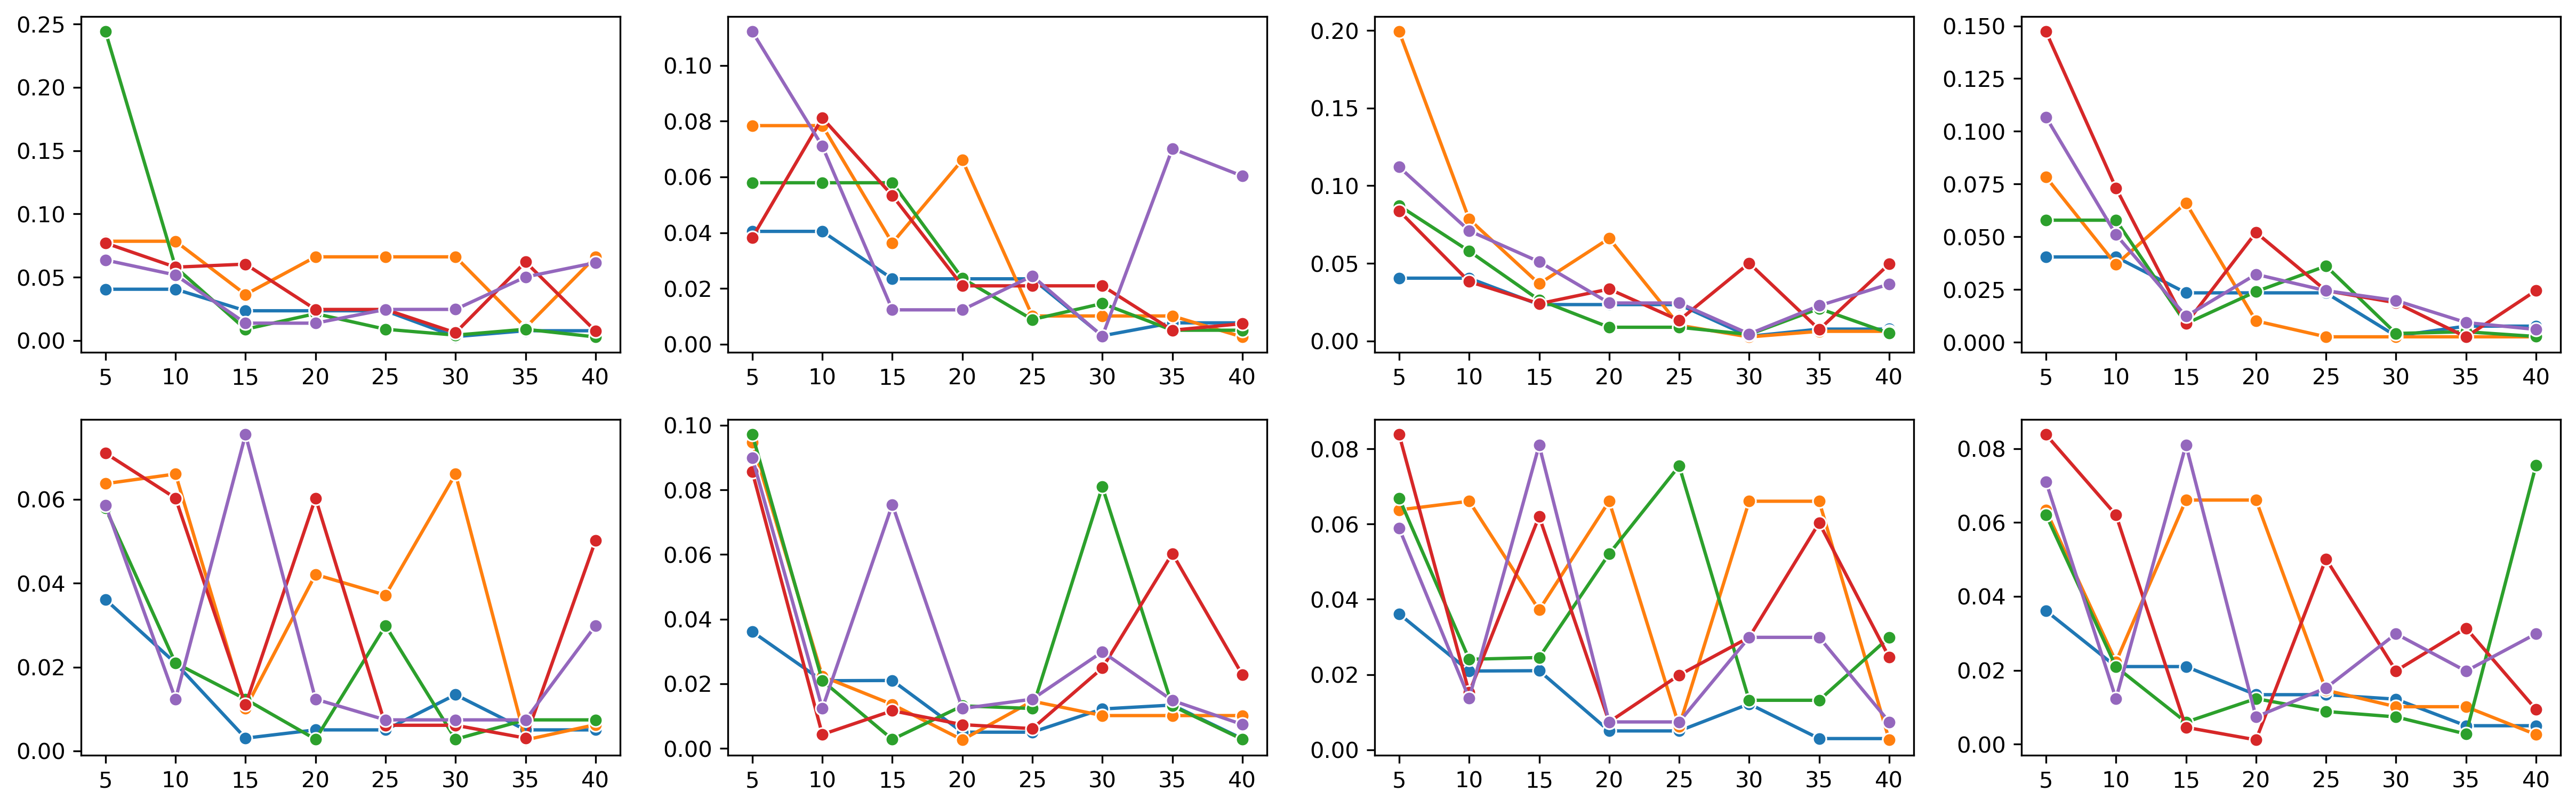

In [ ]:
selected_indices = df_all["learning_mode"] == "random"

# selected_indices = df_all["learning_mode"] == "success"
# selected_indices = df_all["learning_mode"] == "conformist"
# selected_df = df_all[selected_indices]
selected_df = df_all
selected_df = df_all[df_all["learning_mode"] != "conformist"]
k_orders = sorted(selected_df["k_order"].unique())
learning_modes = sorted(selected_df["learning_mode"].unique())
print("Learning Modes: ", learning_modes)
print("K Orders: ", k_orders)
# Plot results
ax_width, ax_height = 5, 3
fig, axes = plt.subplots(len(learning_modes), len(k_orders),
                         figsize=(ax_width * len(k_orders), ax_height * len(learning_modes)), dpi=300)
axes = axes.flatten()

for i, learning_mode in enumerate(learning_modes):
    for j, k_order in enumerate(k_orders):
        # sns.lineplot(data=selected_df, x="env_period", y="optimal_rate", hue="graph_type", marker="o",) # style="graph_type", )
        # # plt.title("Optimal Innovation Rate vs Environmental Stability (Graph-Based Learning Modes)")
        # plt.xlabel("Environmental Stability")
        # plt.ylabel("Optimal Innovation Rate")
        # plt.grid(True)
        # plt.tight_layout()
        print(i, j)
        ax = axes[i * len(k_orders) + j]
        _df = selected_df[
            (selected_df["learning_mode"] == learning_mode) & (selected_df["k_order"] == k_order)
        ]
        sns.lineplot(
            data=_df,
            x="env_period",
            y="optimal_rate",
            hue="graph_type",
            marker="o",
            ax=ax,
            ci=True,
        )  # style="graph_type", )
        # sns.scatterplot(
        #     data=_df,
        #     x="env_period",
        #     y="optimal_rate",
        #     hue="graph_type",
        #     marker="o",
        #     ax=ax,
        # )
        # ax.set_title(f"Learning Mode: {learning_mode}")
        # ax.set_xlabel("Environmental Stability")
        # ax.set_ylabel("Optimal Innovation Rate")
        # hide y label
        # Set legend font-size
        # ax.legend(fontsize=6)
        # Hide legend
        ax.legend_.remove()
        ax.set_ylabel("")
        ax.set_xlabel("")

Learning Modes:  ['random', 'success']
Graph Types:  ['Barabási-Albert', 'Complete', 'Cycle', 'Erdős-Rényi', 'Watts-Strogatz']


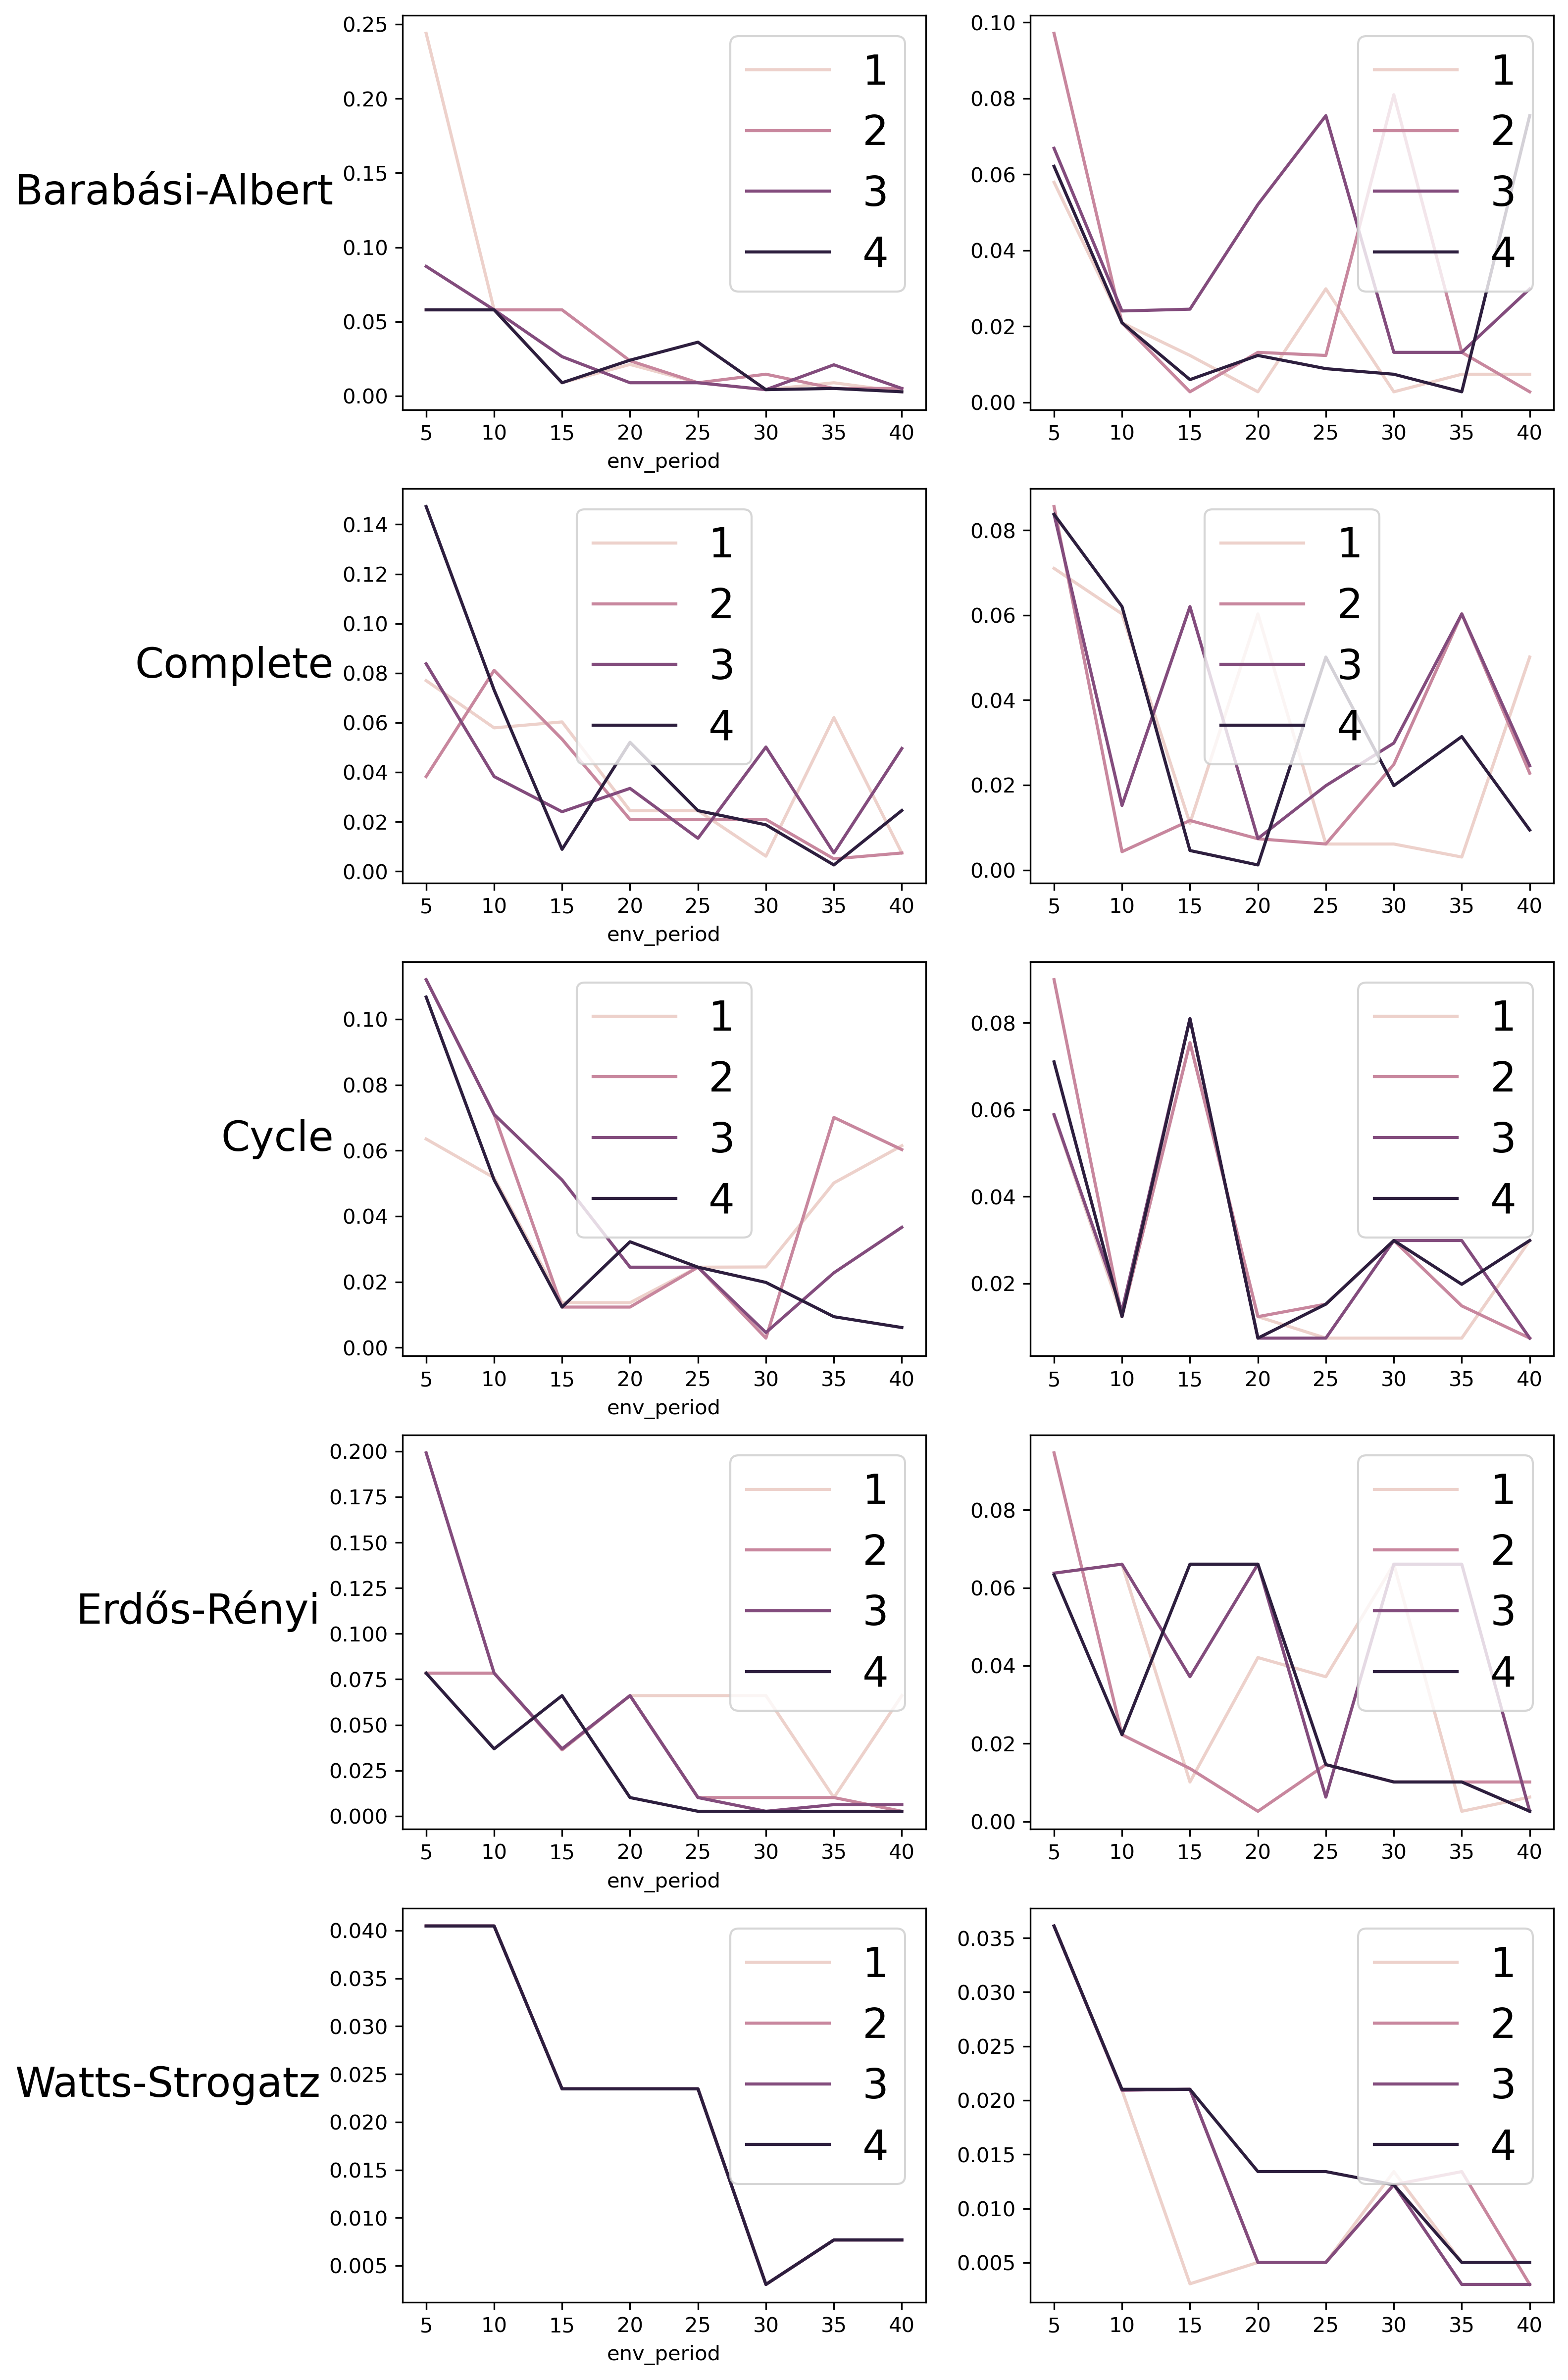

In [ ]:
                                                                                    selected_indices = df_all["learning_mode"] == "random"

# selected_indices = df_all["learning_mode"] == "success"
# selected_indices = df_all["learning_mode"] == "conformist"
# selected_df = df_all[selected_indices]
# selected_df = df_all
selected_df = df_all[df_all["learning_mode"] != "conformist"]
graph_types = sorted(selected_df["graph_type"].unique())
learning_modes = sorted(selected_df["learning_mode"].unique())
print("Learning Modes: ", learning_modes)
print("Graph Types: ", graph_types)
# Plot results
ax_width, ax_height = 5, 5
fig, axes = plt.subplots(len(graph_types), len(learning_modes), 
                         figsize=(ax_width * len(learning_modes), ax_height * len(k_orders)), dpi=300)
axes = axes.flatten()
for i, graph_type in enumerate(graph_types):
    for j, learning_mode in enumerate(learning_modes):
    
        # sns.lineplot(data=selected_df, x="env_period", y="optimal_rate", hue="graph_type", marker="o",) # style="graph_type", )
        # # plt.title("Optimal Innovation Rate vs Environmental Stability (Graph-Based Learning Modes)")
        # plt.xlabel("Environmental Stability")
        # plt.ylabel("Optimal Innovation Rate")
        # plt.grid(True)
        # plt.tight_layout()
        ax = axes[i * len(learning_modes) + j]
        _df = selected_df[
            (selected_df["learning_mode"] == learning_mode) & (selected_df["graph_type"] == graph_type)
        ]
        # sns.scatterplot(
        #     data=_df,
        #     x="env_period",
        #     y="optimal_rate",
        #     hue="k_order",
        #     ax=ax,
        #     # ci=True,
        # )  # style="graph_type", )\
        sns.lineplot(
            data=_df,
            x="env_period",
            y="optimal_rate",
            hue="k_order",
            ax=ax,
            # ci=True,
        )  # style="graph_type", )
        if j == 0:
            ax.set_ylabel(f"{graph_type}", fontsize=20)
            ax.yaxis.label.set(rotation='horizontal', ha='right');
            # Make y label horizontal
        # ax.set_xlabel("Environmental Stability")
        # ax.set_ylabel("Optimal Innovation Rate")
        # hide y label
        else:
            ax.set_ylabel("")  
            ax.set_xlabel("")
        
        # Enlarge legend
        ax.legend(fontsize=20)

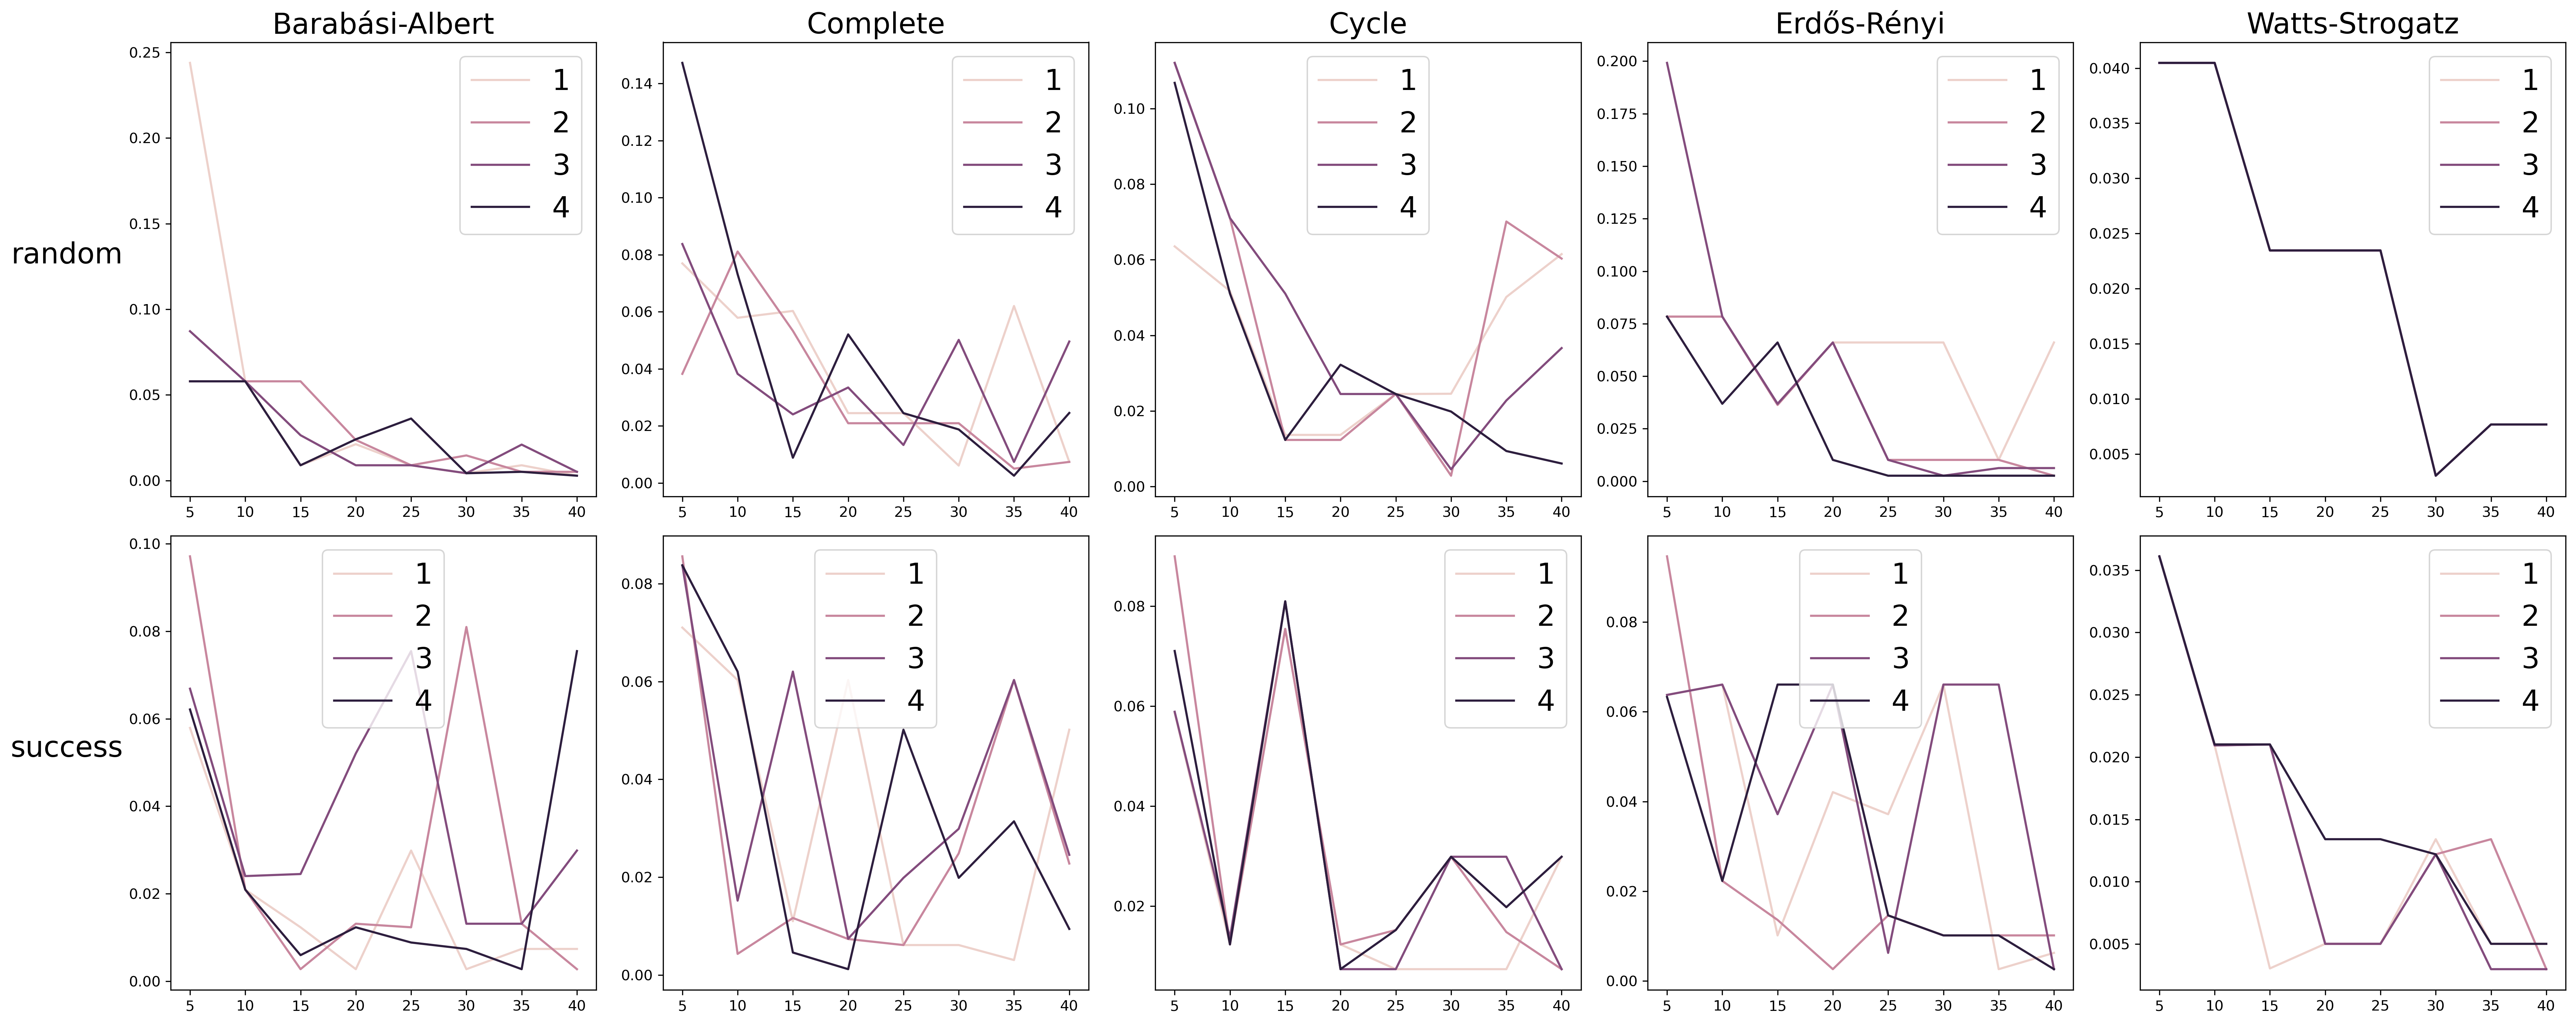

In [ ]:
# Swap rows and columns: now learning_modes are rows, graph_types are columns
fig, axes = plt.subplots(len(learning_modes), len(graph_types), 
                         figsize=(ax_width * len(graph_types), ax_height * len(learning_modes)), dpi=300)
axes = axes.flatten()

for i, learning_mode in enumerate(learning_modes):
    for j, graph_type in enumerate(graph_types):

        ax = axes[i * len(graph_types) + j]
        _df = selected_df[
            (selected_df["learning_mode"] == learning_mode) & (selected_df["graph_type"] == graph_type)
        ]

        sns.lineplot(
            data=_df,
            x="env_period",
            y="optimal_rate",
            hue="k_order",
            ax=ax,
        )

        if i == 0:
            ax.set_title(f"{graph_type}", fontsize=20)

        if j == 0:
            ax.set_ylabel(f"{learning_mode}", fontsize=20)
            ax.yaxis.label.set(rotation='horizontal', ha='right')
        else:
            ax.set_ylabel("")
        
        ax.set_xlabel("")

        # Enlarge legend
        ax.legend(fontsize=20)

plt.tight_layout()


In [ ]:
selected_df

,graph_type,learning_mode,env_period,init_rate,optimal_rate,k_order,stable,trial_count
32,Watts-Strogatz,random,5,0.023466,0.040474,1,False,6
33,Watts-Strogatz,random,5,0.023466,0.040474,2,False,6
34,Watts-Strogatz,random,5,0.023466,0.040474,3,False,6
35,Watts-Strogatz,random,5,0.023466,0.040474,4,False,6
36,Watts-Strogatz,random,10,0.023466,0.040474,1,False,6
...,...,...,...,...,...,...,...,...
475,Cycle,success,35,0.032797,0.019796,4,False,3
476,Cycle,success,40,0.038316,0.029883,1,False,6
477,Cycle,success,40,0.024493,0.007403,2,False,2
478,Cycle,success,40,0.024493,0.007403,3,False,2


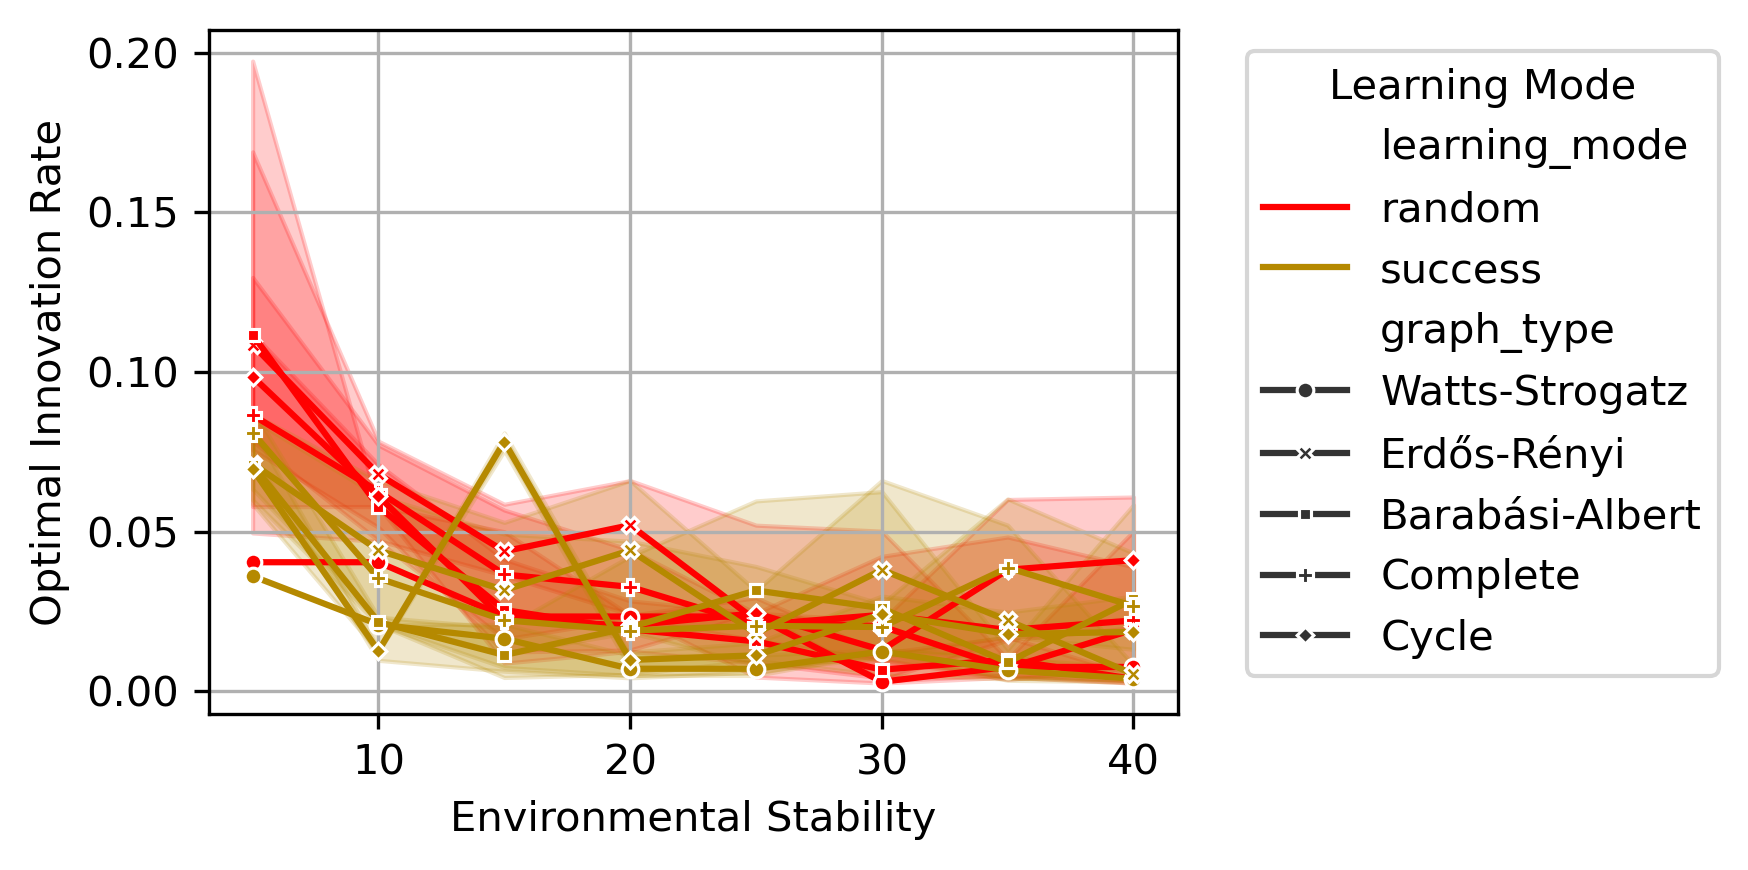

In [ ]:
df_without_conformist = df_all[df_all["learning_mode"] != "conformist"]

plt.figure(figsize=(6, 3), dpi=300)

# Define custom color palette
custom_palette = {
    "random": "red",
    "success": "#b58900"  # Dark yellow (Solarized dark yellow)
}

sns.lineplot(
    data=df_without_conformist,
    x="env_period",
    y="optimal_rate",
    hue="learning_mode",
    style="graph_type",
    markers=True,
    dashes=False,
    markersize=4,
    palette=custom_palette
)

# plt.title("Optimal Innovation Rate vs Environmental Stability (Graph-Based Learning Modes)")
plt.xlabel("Environmental Stability")
plt.ylabel("Optimal Innovation Rate")
plt.grid(True)
plt.legend(title="Learning Mode", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


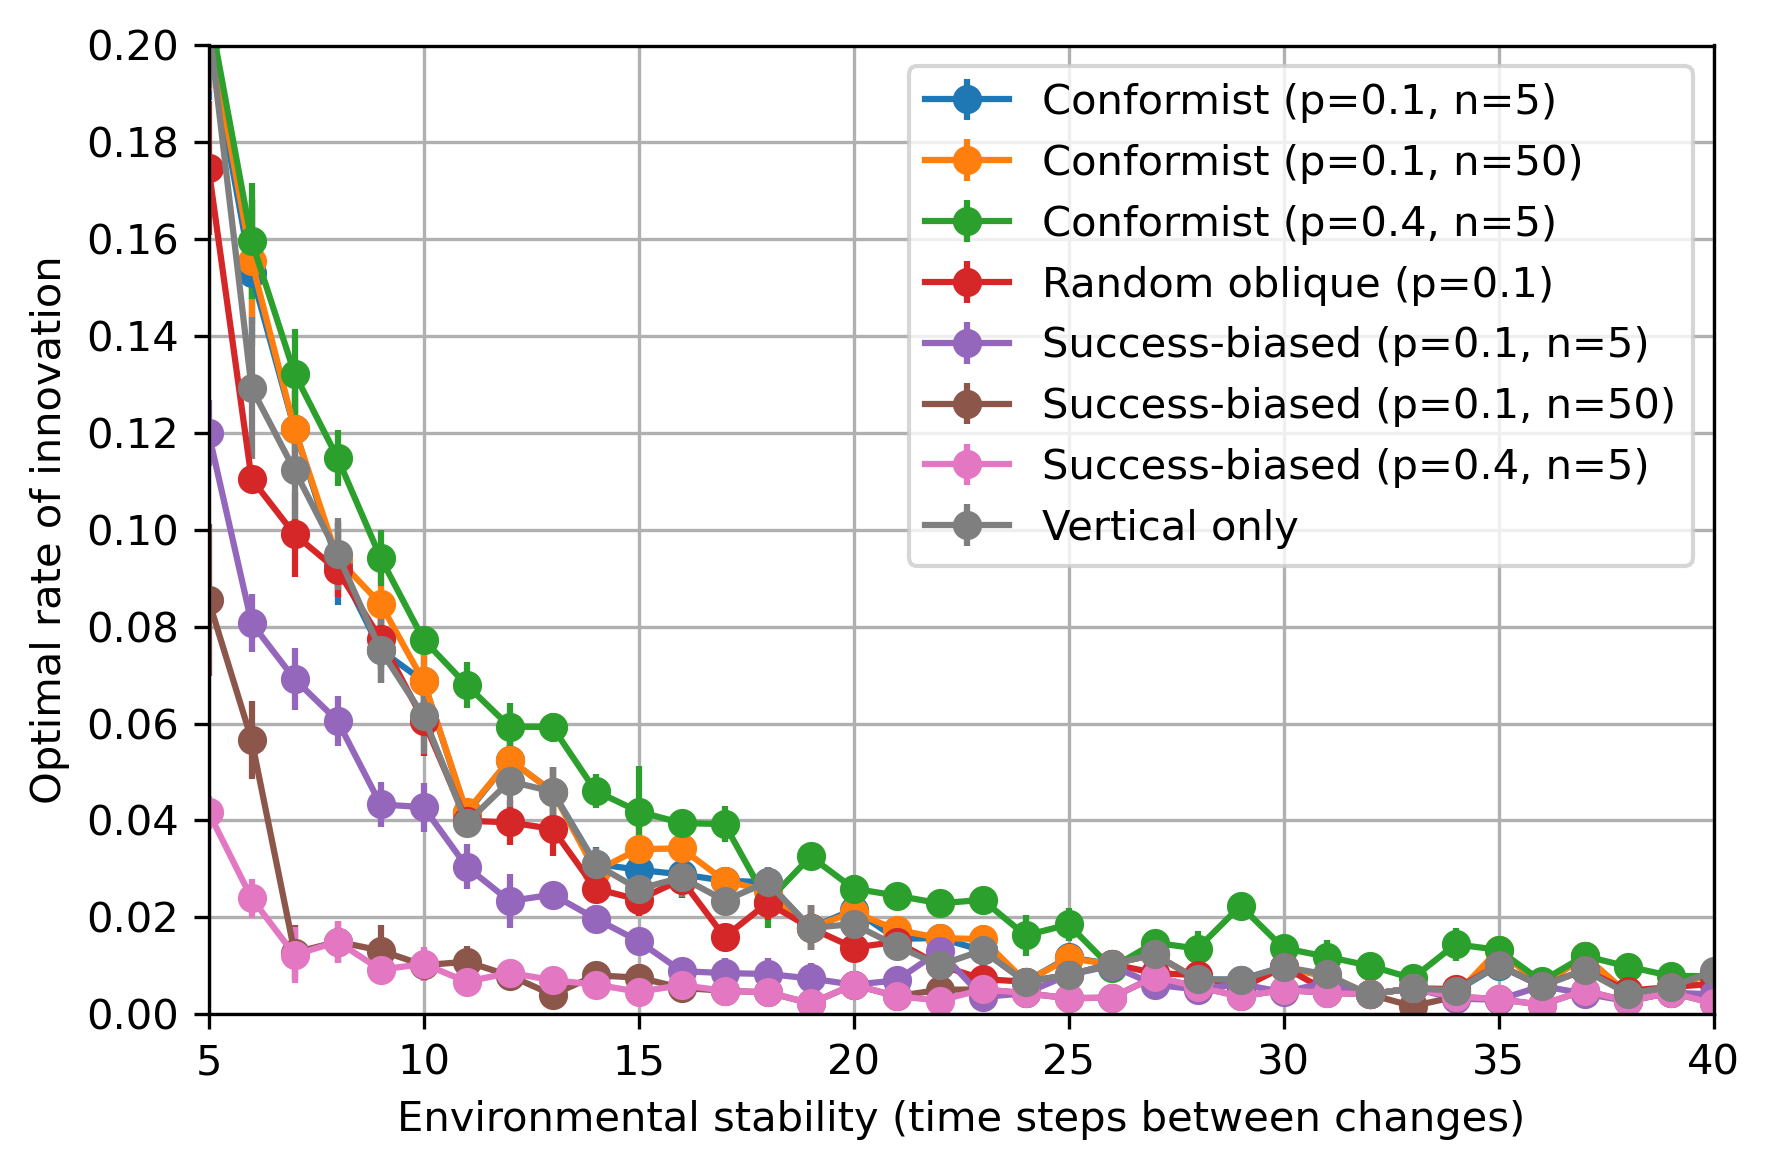

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load summary data
summary_df = pd.read_csv('results_stable_trial-5/figure_1_summary_data.csv')

# Define the labels to keep
included_labels = ["Success-biased (p=0.4, n=5)", "Random oblique (p=0.1)"]

# Filter DataFrame
filtered_df = summary_df

# Define a custom color palette for learning_mode
custom_palette = {
    "random": "red",
    "success": "#b58900"  # Dark yellow (Solarized)
}

# Create the figure
plt.figure(figsize=(6, 4), dpi=300)

# Plot each scenario with color based on learning_mode
for label, group in filtered_df.groupby("scenario_label"):
    learning_mode = group["learning_mode"].iloc[0]
    color = custom_palette.get(learning_mode, "gray")  # fallback to gray if undefined

    plt.errorbar(
        group["environmental_period"],
        group["mean_optimal_rate"],
        yerr=group["std_error"],
        fmt='-o',
        label=label,
    )

# Plot settings
plt.xlabel("Environmental stability (time steps between changes)")
plt.ylabel("Optimal rate of innovation")
# plt.title("Selected Learning Strategies")
plt.ylim(0, 0.2)
plt.yticks(np.arange(0, 0.22, 0.02))
plt.xlim(5, 40)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Save and show
os.makedirs("results", exist_ok=True)
plt.savefig("results/selected_strategies_plot.png", dpi=300)
plt.show()


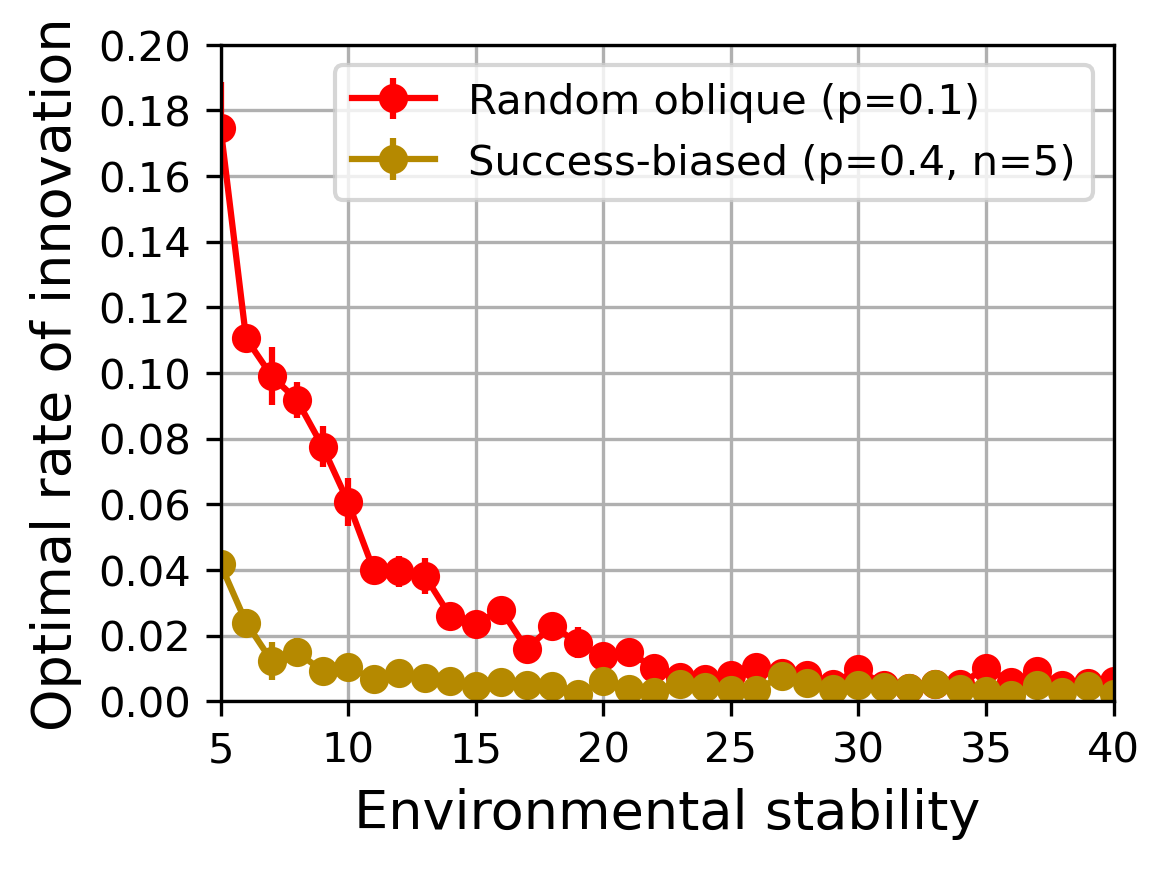

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load summary data
summary_df = pd.read_csv('results_stable_trial-5/figure_1_summary_data.csv')

# Define the labels to keep
included_labels = ["Success-biased (p=0.4, n=5)", "Random oblique (p=0.1)"]

# Filter DataFrame
filtered_df = summary_df[summary_df["scenario_label"].isin(included_labels)]

# Define a custom color palette for learning_mode
custom_palette = {
    "random": "red",
    "success": "#b58900"  # Dark yellow (Solarized)
}

# Create the figure
plt.figure(figsize=(4, 3), dpi=300)

# Plot each scenario with color based on learning_mode
for label, group in filtered_df.groupby("scenario_label"):
    learning_mode = group["learning_mode"].iloc[0]
    color = custom_palette.get(learning_mode, "gray")  # fallback to gray if undefined

    plt.errorbar(
        group["environmental_period"],
        group["mean_optimal_rate"],
        yerr=group["std_error"],
        fmt='-o',
        label=label,
        color=color
    )

# Plot settings
plt.xlabel("Environmental stability", fontsize=13)
plt.ylabel("Optimal rate of innovation", fontsize=13)
# plt.title("Selected Learning Strategies")
plt.ylim(0, 0.2)
plt.yticks(np.arange(0, 0.22, 0.02))
plt.xlim(5, 40)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Save and show
os.makedirs("results", exist_ok=True)
plt.savefig("results/selected_strategies_plot.png", dpi=300)
plt.show()
